In [1]:
# !pip3 install -r ../requirements.txt

In [2]:
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.layers import Dense, Flatten, Input, Dropout, BatchNormalization
from keras.models import Sequential, Model
from keras.optimizers import SGD
from keras.applications import MobileNetV2
from keras.regularizers import l2

os.chdir('../../') # move two level up to the base path
from src.utils import load_and_preprocess_images, plot_history, plot_images, plot_predictions

In [3]:
# set the random seeds to make sure that the results are reproducible
SEED = 1234
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

In [4]:
model_name = 'baseline_cnn'
repo_path = '/Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection'

syntheticDataPath = repo_path + '/data/synthetic'
syntheticTrainingPath = syntheticDataPath + '/TrainingSet/TrainingSet'
syntheticTestPath = syntheticDataPath + '/TestSet/TestSet'

realDataPath = repo_path + '/data/real'
realTrainingPath = realDataPath + '/TrainingSet'
realTestPath = realDataPath + '/TestSet'

In [5]:
comment = "final_version"
model_file_path = repo_path + f"/models/{model_name}/weights/{comment}_model.keras"
ckpt_file_path = repo_path + f"/models/{model_name}/ckpt/{comment}_checkpoint.model.keras"
history_file_path = repo_path + f"/models/{model_name}/history/{comment}_history.csv"
assert not os.path.exists(ckpt_file_path), "Model already exists. Please change the comment."

In [6]:
# Hyperparameters
BATCH_SIZE = 64
IMAGE_SIZE = (224, 224)
INPUT_SHAPE = IMAGE_SIZE + (3,)

MN_OUTPUT_LAYER = 'block_16_project_BN'
UNFREEZE_FROM_LAYER = 'block_16_project_BN'
DATA_AUG_RATE = 0.1
EPOCHS = 100
REGULARIZATION = 0.01
DROPOUT = 0.3
LEARNING_RATE = 0.0001
LOSS_FUNCTION = 'sparse_categorical_crossentropy'
OPTIMIZER = SGD(learning_rate=LEARNING_RATE)

In [7]:
synth_train_data = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, data_aug_rate=DATA_AUG_RATE, subset='training', validation_split=0.2)
synth_valid_data = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, subset='validation', validation_split=0.2)
synth_test_data = load_and_preprocess_images(syntheticTestPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=False)

Found 1704 files belonging to 2 classes.
Using 1364 files for training.
Found 1704 files belonging to 2 classes.
Using 340 files for validation.
Found 4232 files belonging to 2 classes.


In [8]:
real_train_data = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, data_aug_rate=DATA_AUG_RATE, subset='training', validation_split=0.2)
real_valid_data = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, subset='validation', validation_split=0.2)
real_test_data = load_and_preprocess_images(realTestPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=False)

Found 3876 files belonging to 2 classes.
Using 3101 files for training.
Found 3876 files belonging to 2 classes.
Using 775 files for validation.
Found 970 files belonging to 2 classes.


In [9]:
def initialize_baseline_model(title, mn_output_layer, unfreeze_from_layer, loss_function, optimizer, dropout_rate, regularization_rate, input_shape=INPUT_SHAPE):

    # Load the MobileNetV2 model    
    pretrained_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    # Freeze the pretrained weights
    pretrained_model.trainable = False

    # Unfreeze the layers starting from unfreeze_from_layer (exclusive)
    unfreeze = False
    for layer in pretrained_model.layers:
        if unfreeze:
            layer.trainable = True
        elif layer.name == unfreeze_from_layer:
            layer.trainable = False
            unfreeze = True

    # Ensure BN layers are in inference mode (batch norm layers are not trainable)
    for layer in pretrained_model.layers:
        if isinstance(layer, BatchNormalization):
            layer.trainable = False
        
    last_layer = pretrained_model.get_layer(mn_output_layer)
    base_model = Model(inputs=pretrained_model.input, outputs=last_layer.output)

    model = Sequential(name=title)
    model.add(Input(shape=input_shape))
    model.add(base_model)
    model.add(Flatten())

    model.add(Dense(256, activation='relu', kernel_regularizer=l2(regularization_rate)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(regularization_rate)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(2, activation='softmax'))

    model.compile(loss=loss_function, optimizer=optimizer, metrics=['accuracy'])

    return model

In [10]:
early_stop = EarlyStopping(monitor="val_accuracy", mode="max", patience=20, start_from_epoch=10)
checkpoint = ModelCheckpoint(ckpt_file_path, monitor="val_accuracy", mode="max", save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=10, min_lr=0.00001, verbose=1)

model = initialize_baseline_model(title=model_name, mn_output_layer=MN_OUTPUT_LAYER, unfreeze_from_layer=UNFREEZE_FROM_LAYER, loss_function=LOSS_FUNCTION, optimizer=OPTIMIZER, dropout_rate=DROPOUT, regularization_rate=REGULARIZATION)

In [11]:
model.summary(show_trainable=True)

In [12]:
history = model.fit(
    real_train_data,
    validation_data=real_valid_data,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint, reduce_lr]
    )

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 682ms/step - accuracy: 0.4831 - loss: 8.0330
Epoch 1: val_accuracy improved from -inf to 0.76000, saving model to /Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection/models/baseline_cnn/ckpt/test1234_checkpoint.model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 48s 921ms/step - accuracy: 0.4840 - loss: 8.0295 - val_accuracy: 0.7600 - val_loss: 7.2795 - learning_rate: 1.0000e-04
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 709ms/step - accuracy: 0.6769 - loss: 7.4750
Epoch 2: val_accuracy improved from 0.76000 to 0.85548, saving model to /Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection/models/baseline_cnn/ckpt/test1234_checkpoint.model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 43s 883ms/step - accuracy: 0.6773 - loss: 7.4741 - val_accuracy: 0.8555 - val_loss: 7.1173 - learning_rate: 1.0000e-04
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 699ms/step - accuracy: 0.7720 - loss: 7.2751
Epoch 3: val_accuracy improved from 0.85548 to 

In [13]:
# save the history
history_df = pd.DataFrame(history.history)
history_df['epoch'] = history.epoch
history_df.to_csv(history_file_path, index=False)

In [14]:
# load the best model
model.load_weights(ckpt_file_path)

# save the model
model.save(model_file_path)

In [17]:
# evaluate the model
loss, accuracy = model.evaluate(real_test_data)
print(f"Test loss: {loss}")
print(f"Test accuracy: {accuracy}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 604ms/step - accuracy: 0.9285 - loss: 6.9530
Test loss: 6.938974857330322
Test accuracy: 0.9319587349891663


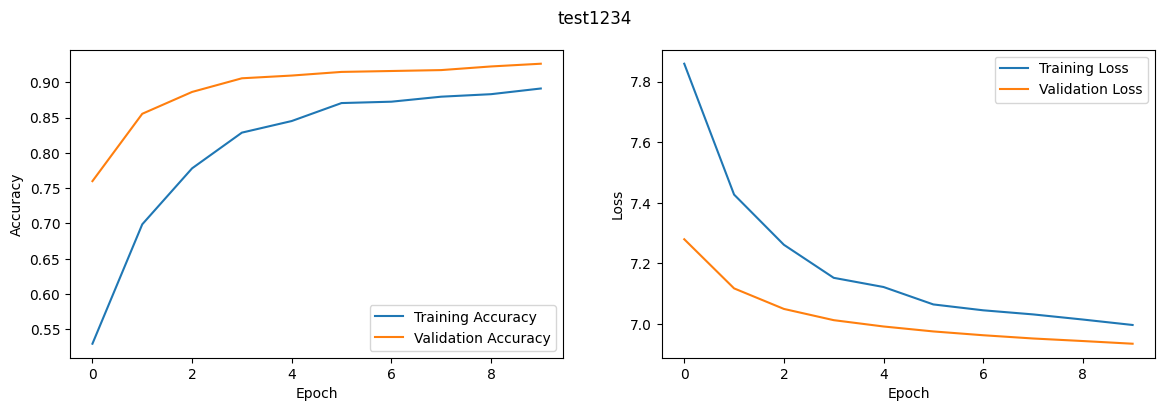

Best train_accuracy: 0.8913
Best train_loss: 6.9965
Best val_accuracy: 0.9265
Best val_loss: 6.9347
Last improvement at epoch: 10


In [16]:
plot_history(comment, history)

Found 3876 files belonging to 2 classes.
Using 3101 files for training.
Found 3876 files belonging to 2 classes.


2024-07-10 10:35:24.041999: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2024-07-10 10:35:24.866270: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-07-10 10:35:24.965849: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.

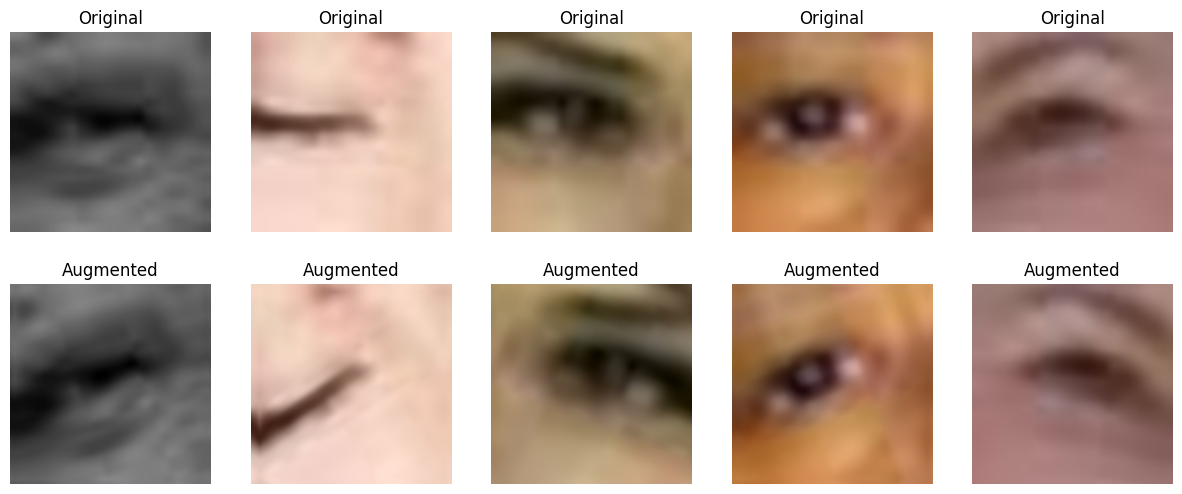

In [ ]:
real_train_data_augm = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, data_aug_rate=DATA_AUG_RATE, subset='training', validation_split=0.2, skip_preprocessing=True)
real_train_data_orig = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, skip_preprocessing=True)

# Plotting original and augmented images
plot_images(img_orig=real_train_data_orig, img_augm=real_train_data_augm)

Found 3876 files belonging to 2 classes.
Using 775 files for validation.


2024-07-10 10:35:25.426090: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 275ms/step


2024-07-10 10:35:26.499002: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


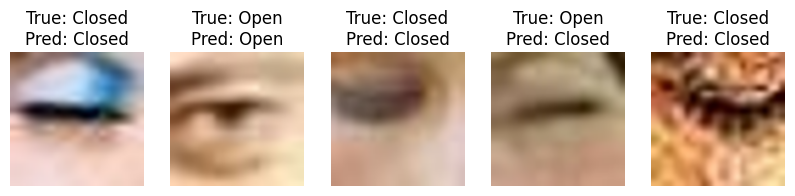

In [ ]:
real_valid_data_skip_preprocessing = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, data_aug_rate=DATA_AUG_RATE, seed=SEED, subset='validation', validation_split=0.2, skip_preprocessing=True)

plot_predictions(model=model, dataset=real_valid_data, dataset_visual=real_valid_data_skip_preprocessing)